<a href="https://colab.research.google.com/github/MachineLearning30110/MachineLearning-Models/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [3]:
df = df[df["target"] != 2]  # keep only classes 0 and 1

In [4]:
X = df.drop("target", axis=1)
y = df["target"]

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [31]:
preds = model.predict(X_test)
probs = model.predict_proba(X_test)

print("Predictions:", preds[:5])
print("Probabilities:", probs[:5])

Predictions: [1 1 1 0 0]
Probabilities: [[0.00118455 0.99881545]
 [0.01579803 0.98420197]
 [0.00304709 0.99695291]
 [0.96959941 0.03040059]
 [0.94269372 0.05730628]]


In [32]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 1.0


**Log Loss (Cross Entropy Loss)**

    Loss= -1/n ( ​∑ [ y * log(y^​) + (1−y) * log(1−y^​) ] )

    n = number of samples
    y = actual output (0 or 1)
    y^ = predicted probability

In [33]:
from sklearn.metrics import log_loss

loss = log_loss(y_test, probs)

print("Log Loss:", loss)

Log Loss: 0.02128721299816193


In [37]:
import numpy as np

def cross_entropy(y_true, y_pred):
    epsilon = 1e-15  # avoid log(0)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    return -np.mean(
        y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)
    )

print(cross_entropy(y_test, probs[:,1]))

0.02128721299816193


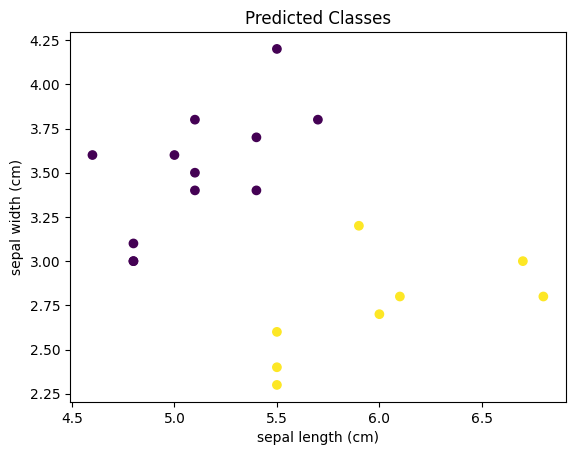

In [26]:
import matplotlib.pyplot as plt

feature1 = "sepal length (cm)"
feature2 = "sepal width (cm)"

plt.scatter(X_test[feature1], X_test[feature2], c=preds)
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title("Predicted Classes")
plt.show()